# CVineMarketGen — worked examples

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples.ipynb)

Two examples, each following the pipeline of the paper *Vine-Copula Based Financial
Market Simulation with Moment and Tail Dependence Targeting* (thesis, article 3):

1. **LTCMA targeting** — 4 asset classes (U.S. Large Cap, U.S. Long Treasuries,
   Commodities, Gold) with J.P. Morgan's 2024 Long-Term Capital Market Assumptions
   as targets for the mean, the volatility and the correlation matrix.
2. **Macro factors** — 6 factors (Equity DM, Equity EM, Real premia, Inflation,
   Credit, Commodity) built at run time from point-in-time market data (Fama-French,
   FRED, Yahoo Finance), with **no target other than the history itself**.

In Example 1 a *synthetic* history is **simulated from a C-vine with known copula
families**, so that the family selection (Algorithm 3) can be checked against the
truth. In both examples the vine is **calibrated to the targets** (Algorithm 4) and a
scenario matrix is **simulated back** (Algorithm 5). The **Fleishman + Vale-Maurelli**
generator (Section 3 of the paper) is run on the same targets as a benchmark, and
the exceedance-correlation curves of the three series are compared.

Everything is seeded and reproducible. No data file is shipped with the package.

In [1]:
import os, sys, time, warnings, io, contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
sys.path.insert(0, os.getcwd())          # allows running from a local clone

try:
    import cvinemarketgen                 # local clone or already installed
except ImportError:                       # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git"], check=True)
    import cvinemarketgen

from cvinemarketgen import CVineGenerator, FleishmanGenerator

RAW = "https://raw.githubusercontent.com/mamadouyamar/CVineMarketGen/main/data/"
def load_targets(name):
    path = os.path.join("data", name)
    return pd.read_csv(path if os.path.exists(path) else RAW + name, index_col="Assets")

N_HIST = 3000      # length of the synthetic "historical" series
N_OPT  = 10000     # draws used inside the correlation-targeting optimizer (paper: 20000)
N_SIM  = 25000     # scenarios in the final simulated matrix (paper: 25000)
CORR_TOL = 5e-2    # acceptance tolerance on pairwise correlations (paper: 2e-2 with N_OPT = 20000)
SEED = 1

def make_generator():
    return CVineGenerator(tol_opt=1e-10, n_samples=N_OPT,
                          use_ncs_on_firsttree=False, use_ncs_on_deepertrees=False,
                          use_mixture_on_firsttree=True, use_mixture_on_deepertrees=False,
                          force_try_ncscopula=False, tol_for_optimization_func=1e-6)

def show_moments(name, cal, t):
    print(f"== {name}  (N={N_SIM}, {t:.0f}s) ==")
    cols = ['mean (target)', 'mean (calibrated)', 'volatility (target)', 'volatility (calibrated)',
            'skewness (target)', 'skewness (calibrated)', 'kurtosis (target)', 'kurtosis (calibrated)']
    print(cal[cols].round(4).to_string())
    print("max |diff| mean, vol, skew, kurt:",
          [f"{cal[c].abs().max():.1e}" for c in ['diff mean', 'diff volatility', 'diff skewness', 'diff kurtosis']])

def show_corr(name, target, sim):
    d = (sim.corr().values - target.values) * 100
    lo = d[np.tril_indices(len(target), -1)]
    print(f"{name}: correlation error in percentage points -> max |.| {np.abs(lo).max():.2f}, mean |.| {np.abs(lo).mean():.2f}")

def plot_exceedance(gen, base, others, series, targets, ncols=3, zlim=1.0):
    z = np.arange(-zlim, zlim + 0.025, 0.05)
    n = len(others); nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows), squeeze=False)
    style = {'Historical': dict(color='black', lw=2), 'C-vine': dict(color='tab:blue', lw=1.6),
             'Fleishman': dict(color='tab:orange', lw=1.6, ls='--')}
    for ax, a in zip(axes.flat, others):
        for name, df in series.items():
            ax.plot(z, gen.exceedance_correlation(df[base].values, df[a].values, z), label=name, **style[name])
        ax.axvline(0, color='grey', lw=0.6, ls=':'); ax.axhline(targets.loc[base, a], color='grey', lw=0.6, ls=':')
        ax.set_title(f"{base} vs {a}  (target {targets.loc[base, a]:+.2f})", fontsize=9)
        ax.set_xlabel(f"threshold on {base} (std)", fontsize=8); ax.tick_params(labelsize=8); ax.grid(alpha=0.25)
    for ax in axes.flat[n:]:
        ax.axis('off')
    h, l = axes.flat[0].get_legend_handles_labels()
    fig.legend(h, l, loc='lower center', ncol=3, frameon=False); fig.tight_layout(rect=(0, 0.05, 1, 1)); plt.show()

quiet = lambda: contextlib.redirect_stdout(io.StringIO())   # silences the pipeline's progress prints

print("setup done")

setup done


## Example 1 — LTCMA targeting (4 asset classes)

**Targets:** mean, volatility and correlations of U.S. Large Cap, U.S. Long Treasuries,
Commodities and Gold from J.P. Morgan's 2024 LTCMAs (`data/jpm_ltcma_2024.csv`,
public figures). U.S. Large Cap is the central node of the C-vine.

**Synthetic history, simulated with known families** (indices $\theta_{ik|1:k-1}$ of the paper):
the (Long Treasuries, Large Cap) edge is a *mixture* of a Clayton 270° and a Gumbel
copula, which produces the sign change of the conditional correlation ("flight to
quality"); (Commodities, Large Cap) is a Gumbel 180° (lower-tail dependence);
(Gold, Large Cap) is Gaussian with $\rho = 0.05$; deeper trees are Gaussian. The
Johnson SU marginals are those fitted in the paper for these four assets.

In [2]:
assets = ['U.S. Large Cap', 'U.S. Long Treasuries', 'Commodities', 'Gold']
ltcma = load_targets("jpm_ltcma_2024.csv").loc[assets, ['Arithmetic Mean', 'Volatility'] + assets]
target_corr = ltcma[assets]
print(ltcma.round(3).to_string())

edges = {(2, 1): ('mixture', [('clayton', 270, 0.66), ('gumbel', 0, 1.84)], 0.70),   # Long Treasuries | Large Cap
         (3, 1): ('gumbel', 180, 1.38),                                              # Commodities     | Large Cap
         (4, 1): ('gaussian', 0, 0.05),                                              # Gold            | Large Cap
         (3, 2): ('gaussian', 0, -0.15), (4, 2): ('gaussian', 0, 0.30), (4, 3): ('gaussian', 0, 0.20)}
jsu = {'U.S. Large Cap': (2.570, 2.179, 3.540, 2.646), 'U.S. Long Treasuries': (-0.096, -0.095, 2.279, 2.062),
       'Commodities': (0.611, 0.589, 2.092, 1.774), 'Gold': (-0.523, -0.516, 2.893, 2.675)}   # (gamma, xi, delta, lambda)

gen = make_generator()
spec = gen.make_vine_spec(assets, edges)
hist = gen.simulate_known_vine(spec, jsu, ltcma['Arithmetic Mean'], ltcma['Volatility'], assets, n=N_HIST, seed=SEED)
print(f"\nsynthetic history: {hist.shape[0]} observations")
print(gen.true_edge_table(assets, edges).to_string(index=False))

                      Arithmetic Mean  Volatility  U.S. Large Cap  U.S. Long Treasuries  Commodities   Gold
Assets                                                                                                     
U.S. Large Cap                  0.082       0.162           1.000                -0.096        0.455  0.033
U.S. Long Treasuries            0.059       0.124          -0.096                 1.000       -0.231  0.312
Commodities                     0.053       0.180           0.455                -0.231        1.000  0.356
Gold                            0.054       0.169           0.033                 0.312        0.356  1.000

synthetic history: 3000 observations
 tree                                                      edge              true family           true parameters
    1                     U.S. Long Treasuries , U.S. Large Cap clayton 270° + gumbel 0° w=0.7, theta=(0.66, 1.84)
    1                              Commodities , U.S. Large Cap              gumbel 

### Family selection (Algorithm 3)

`load_data_and_setup` computes the target skewness and kurtosis from the history and
fits the Johnson SU marginals; `fit_and_structure_CVine` classifies every edge from its
exceedance-correlation curve, pre-selects the admissible families, fits them by maximum
likelihood and keeps the best BIC. Compare with the true table above.

In [3]:
np.random.seed(SEED)
t0 = time.time()
with quiet():
    setup = gen.load_data_and_setup(ltcma, hist, assets)
    fit = gen.fit_and_structure_CVine(setup)
print(f"\nselection done in {time.time() - t0:.0f}s")
print(gen.selected_edge_table(assets, fit).to_string(index=False))


selection done in 5s
 tree                                                      edge           selected family                   parameters
    1                     U.S. Long Treasuries , U.S. Large Cap  clayton 270° + gumbel 0° w=0.69, theta=(0.608, 1.948)
    1                              Commodities , U.S. Large Cap               gumbel 180°                  theta=1.396
    1                                     Gold , U.S. Large Cap clayton 180° + gumbel 90° w=0.15, theta=(0.588, 1.000)
    2       Commodities , U.S. Long Treasuries | U.S. Large Cap               gaussian 0°                 theta=-0.142
    2              Gold , U.S. Long Treasuries | U.S. Large Cap               gaussian 0°                  theta=0.293
    3 Gold , Commodities | U.S. Large Cap, U.S. Long Treasuries               gaussian 0°                  theta=0.174


### Calibration to the LTCMA correlations (Algorithm 4) and simulation (Algorithm 5)

The copula parameters are re-calibrated, variable by variable, so that the simulated
correlations match the LTCMA targets while the selected families are preserved. Then a
matrix of `N_SIM` scenarios is drawn, the marginal parameters are re-fitted on the draw,
and the draw is accepted if it meets the tolerances (2e-4 on mean and volatility, 5e-2
on skewness and kurtosis, `CORR_TOL` on all correlations).

In [4]:
t0 = time.time()
with quiet():
    vine = gen.run_vine_optimization(setup, fit)
    sims, cals, targets = gen.run_multi_year_simulation(vine, n_year=1, n_per_year=N_SIM, corr_tol=CORR_TOL)
cal = cals[0]
t_vine = time.time() - t0
vine_sim = sims[0]
print(f"\ncalibration + simulation done in {t_vine:.0f}s\n")
print(gen.selected_edge_table(assets, fit, vine).to_string(index=False)); print()
show_moments("C-vine, 4 assets", cal, t_vine)
show_corr("C-vine", target_corr, vine_sim)


calibration + simulation done in 164s

 tree                                                      edge           selected family                   parameters
    1                     U.S. Long Treasuries , U.S. Large Cap  clayton 270° + gumbel 0° w=0.73, theta=(0.646, 1.937)
    1                              Commodities , U.S. Large Cap               gumbel 180°                  theta=1.379
    1                                     Gold , U.S. Large Cap clayton 180° + gumbel 90° w=0.21, theta=(0.598, 1.032)
    2       Commodities , U.S. Long Treasuries | U.S. Large Cap               gaussian 0°                 theta=-0.204
    2              Gold , U.S. Long Treasuries | U.S. Large Cap               gaussian 0°                  theta=0.319
    3 Gold , Commodities | U.S. Large Cap, U.S. Long Treasuries               gaussian 0°                  theta=0.514

== C-vine, 4 assets  (N=25000, 164s) ==
                     mean (target)  mean (calibrated) volatility (target)  volatility 

### Fleishman + Vale-Maurelli benchmark (Section 3 of the paper)

Same targets (mean, volatility, skewness, kurtosis, correlations): Fleishman
coefficients per asset, Vale-Maurelli intermediate correlations per pair, then a
Gaussian vector transformed asset by asset, with the same accept-reject loop.

In [5]:
ts = setup['df_target_stats']
fg = FleishmanGenerator()
t0 = time.time()
out = fg.fit(ts['Arithmetic Mean'], ts['Volatility'], ts['Skewness'], ts['Kurtosis'] - 3, setup['ltcma_corr'])
print("Fleishman coefficients (a, b, c, d):"); print(out['coef'][['a', 'b', 'c', 'd']].astype(float).round(4).to_string())
print("pairs without a real Vale-Maurelli root:", len(out['infeasible_pairs']))
fleish_sim, ferr, _ = fg.simulate(N_SIM, corr_tol=CORR_TOL, seed=SEED, verbose=False)
print(f"\nsimulation done in {time.time() - t0:.0f}s; max |error| mean, vol, skew, kurt:",
      [f"{ferr[k]:.1e}" for k in ['mean', 'vol', 'skew', 'kurt']])
show_corr("Fleishman", target_corr, fleish_sim)

Fleishman coefficients (a, b, c, d):
                           a       b       c       d
U.S. Large Cap        0.0807  0.9656 -0.0807  0.0092
U.S. Long Treasuries -0.0143  0.9245  0.0143  0.0245
Commodities           0.0744  0.9003 -0.0744  0.0304
Gold                 -0.0143  0.9599  0.0143  0.0131
pairs without a real Vale-Maurelli root: 0

simulation done in 0s; max |error| mean, vol, skew, kurt: ['3.2e-16', '3.6e-06', '4.4e-12', '6.3e-11']
Fleishman: correlation error in percentage points -> max |.| 1.56, mean |.| 0.86


### Exceedance correlation: synthetic history vs the two generators

Correlation between U.S. Large Cap and each other asset, conditional on U.S. Large Cap
being below the threshold $z$ (for $z<0$) or above it (for $z \ge 0$), in standard
deviations. The C-vine generator reproduces the shape of the synthetic history,
including the sign change for Long Treasuries; the Fleishman generator, whose
dependence is Gaussian, gives smooth symmetric curves at the level of the target.

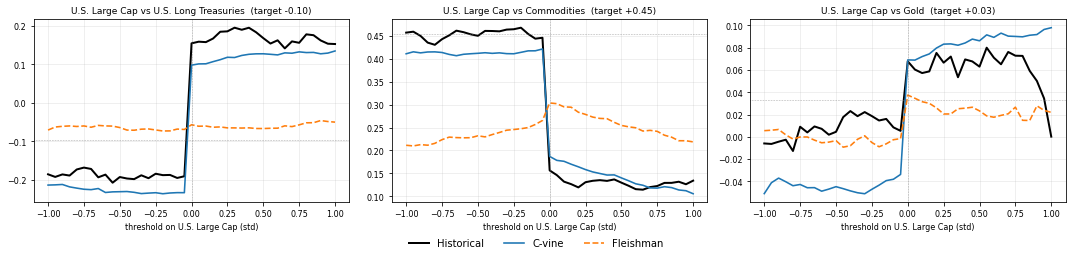

In [6]:
plot_exceedance(gen, assets[0], assets[1:], {'Historical': hist, 'C-vine': vine_sim, 'Fleishman': fleish_sim}, target_corr)

## Example 2 — Macro factors from point-in-time market data (6 factors)

Here there is **no target other than the history**: the sample mean, volatility,
skewness, kurtosis and correlation matrix of six monthly factor excess returns are the
targets, and the copula families are selected on the same sample. The question is
whether each generator reproduces this factor history, tails included.

The factors are built at run time from public market series (nothing is shipped with
the package; `load_factor_data` caches the download in `data/factors_cache.csv`):

| Factor | Construction | Source |
|---|---|---|
| Equity DM | developed-market excess return, Mkt-RF | Fama-French, Developed 3 factors |
| Equity EM | emerging minus developed excess return | Fama-French, Emerging 5 factors minus Developed |
| Real premia | long TIPS / short cash: carry − 8 × change of the 10y TIPS real yield (DFII10) | FRED |
| Inflation | long TIPS / short nominal: carry + 8 × change of the 10y breakeven (T10YIE) | FRED |
| Credit | long Baa corporates / short Treasuries: carry − 10 × change of the Baa − 10y spread (BAA10Y) | FRED |
| Commodity | DBC commodity ETF total return minus the risk-free rate | Yahoo Finance |

The yield-based factors are duration-scaled proxies (Duration-Times-Spread
decomposition for the credit leg); Moody's Baa index is long-maturity, hence the
duration of 10. Equity DM is the central node of the C-vine.

In [7]:
from cvinemarketgen import load_factor_data, factor_targets

factors_ret = load_factor_data(start="2006-03")          # monthly excess returns, decimal
factors = list(factors_ret.columns)
mf = factor_targets(factors_ret)                          # targets = the sample itself (monthly units)
mf_corr = mf[factors]
print()
print(pd.concat([mf[['Arithmetic Mean', 'Volatility']].mul([12, 12 ** 0.5]).rename(columns={'Arithmetic Mean': 'mean (ann.)', 'Volatility': 'vol (ann.)'}),
                 factors_ret.skew().rename('skewness'), (factors_ret.kurtosis() + 3).rename('kurtosis')], axis=1).round(3).to_string())
print("\ncorrelation matrix:"); print(mf_corr.round(2).to_string())

factor data read from cache data/factors_cache.csv: 244 months, 2006-04 to 2026-07

             mean (ann.)  vol (ann.)  skewness  kurtosis
Equity DM          0.080       0.158    -0.641     4.735
Equity EM         -0.007       0.108    -0.024     2.987
Real premia        0.008       0.062    -0.633     5.405
Inflation          0.020       0.047     0.133     9.561
Credit             0.025       0.082    -1.910    17.585
Commodity          0.023       0.188    -0.531     4.963

correlation matrix:
             Equity DM  Equity EM  Real premia  Inflation  Credit  Commodity
Assets                                                                      
Equity DM         1.00       0.10         0.30       0.51    0.61       0.51
Equity EM         0.10       1.00         0.13       0.18    0.21       0.25
Real premia       0.30       0.13         1.00       0.21   -0.02       0.11
Inflation         0.51       0.18         0.21       1.00    0.56       0.58
Credit            0.61       0.21 

### Family selection, calibration and simulation

Same calls as in Example 1, with the factor history in place of the synthetic one.
The family selected for each edge is what Algorithm 3 reads from the exceedance
curves of the sample.

In [8]:
gen_mf = make_generator()
np.random.seed(SEED)
t0 = time.time()
with quiet():
    setup_mf = gen_mf.load_data_and_setup(mf, factors_ret, factors)
    fit_mf = gen_mf.fit_and_structure_CVine(setup_mf)
print(f"selection done in {time.time() - t0:.0f}s")
print(gen_mf.selected_edge_table(factors, fit_mf).to_string(index=False))

t0 = time.time()
with quiet():
    vine_mf = gen_mf.run_vine_optimization(setup_mf, fit_mf)
    sims_mf, cals_mf, _ = gen_mf.run_multi_year_simulation(vine_mf, n_year=1, n_per_year=N_SIM, corr_tol=CORR_TOL)
cal_mf = cals_mf[0]
t_mf = time.time() - t0
vine_sim_mf = sims_mf[0]
print(f"\ncalibration + simulation done in {t_mf:.0f}s\n")
print(gen_mf.selected_edge_table(factors, fit_mf, vine_mf).to_string(index=False)); print()
show_moments("C-vine, 6 factors", cal_mf, t_mf)
show_corr("C-vine", mf_corr, vine_sim_mf)

selection done in 7s
 tree                                                              edge selected family   parameters
    1                                             Equity EM , Equity DM     gumbel 180°  theta=1.069
    1                                           Real premia , Equity DM     gumbel 180°  theta=1.234
    1                                             Inflation , Equity DM     gumbel 180°  theta=1.573
    1                                                Credit , Equity DM     gumbel 180°  theta=1.673
    1                                             Commodity , Equity DM     gumbel 180°  theta=1.499
    2                               Real premia , Equity EM | Equity DM    clayton 180°  theta=0.152
    2                                 Inflation , Equity EM | Equity DM    clayton 180°  theta=0.183
    2                                    Credit , Equity EM | Equity DM       gumbel 0°  theta=1.092
    2                                 Commodity , Equity EM | Equity D

### Fleishman benchmark and exceedance correlation

The curves now compare the two generators with the **actual factor history**.

pairs without a real Vale-Maurelli root: 0
Fleishman max |error| mean, vol, skew, kurt: ['1.3e-17', '1.1e-06', '2.2e-11', '8.6e-11']
Fleishman: correlation error in percentage points -> max |.| 1.29, mean |.| 0.49


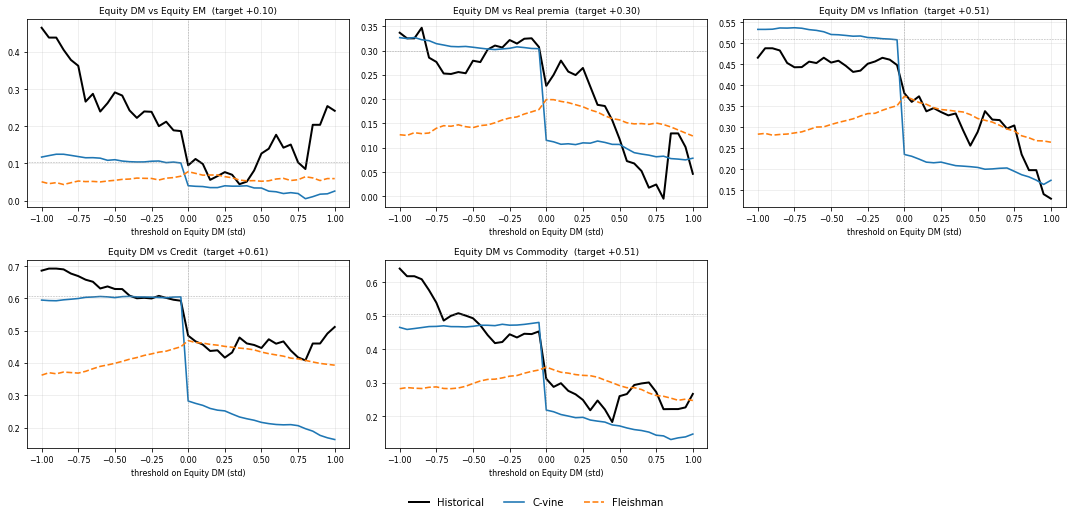

In [9]:
ts_mf = setup_mf['df_target_stats']
fg_mf = FleishmanGenerator()
out_mf = fg_mf.fit(ts_mf['Arithmetic Mean'], ts_mf['Volatility'], ts_mf['Skewness'], ts_mf['Kurtosis'] - 3, setup_mf['ltcma_corr'])
print("pairs without a real Vale-Maurelli root:", len(out_mf['infeasible_pairs']))
fleish_sim_mf, ferr_mf, _ = fg_mf.simulate(N_SIM, corr_tol=CORR_TOL, seed=SEED, verbose=False)
print("Fleishman max |error| mean, vol, skew, kurt:", [f"{ferr_mf[k]:.1e}" for k in ['mean', 'vol', 'skew', 'kurt']])
show_corr("Fleishman", mf_corr, fleish_sim_mf)
plot_exceedance(gen_mf, factors[0], factors[1:], {'Historical': factors_ret, 'C-vine': vine_sim_mf, 'Fleishman': fleish_sim_mf}, mf_corr)

### Reading the results

- **Moments**: both generators re-fit their marginal parameters on the accepted draw, so
  the four moments are matched by construction.
- **Correlations**: both generators reach the targets within `CORR_TOL`. The Fleishman
  generator is usually closer, since the Vale-Maurelli step solves each pairwise
  equation exactly; the C-vine generator matches the correlations numerically under
  the constraint of the selected families.
- **Tail dependence**: only the C-vine generator reproduces the shape of the
  exceedance-correlation curves (jump at zero, sign change on the mixture edges). The
  Fleishman generator inherits the Gaussian copula of its underlying normal vector,
  whose curves are smooth and symmetric.
- **Selection**: near-independent pairs (target correlation close to zero) are not
  identifiable from an exceedance curve, and the selected family may differ from the
  true one (Gold in Example 1); the calibration still reaches the target level.
- **Example 2** has no synthetic truth: the selected families are what the exceedance
  curves of 244 months of factor returns support (a Gumbel 180°, lower-tail dependence,
  on every first-tree edge), and the figure shows how far each generator reproduces
  them. The C-vine reproduces the jump at zero on all five pairs; it undershoots on the
  right side for Credit and Inflation, and the rise of the Equity EM curve deep in the
  left tail is stronger than a Gumbel constrained to a target correlation of 0.10 can
  produce. The 2008 episode makes the credit factor extremely heavy-tailed (kurtosis
  above 17), which both marginal models accommodate, at the cost of the largest
  skewness and kurtosis errors of the notebook (about 1e-2, within the 5e-2 tolerance).

Reference: thesis, article 3, *Vine-Copula Based Financial Market Simulation with
Moment and Tail Dependence Targeting*, Sections 3 to 5 and Appendix C.